In [7]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D

sys.path.append('../..')

from src.piece_functions import generate_random_trajectory

from src.embedding_trans import EmbeddingTrans
from src.markov_analysis import Markov



### Generate trajectories
Here we study how changes in characteristics of the trajectory reflects in the markov model we derive later. To do so, we first build _ samples with the following characteristics:
1. This is a reference made only with persistent random walk and straight lines.
2. Same as first, with a different rate of straight lines.
3. Same as first, with a faster straight line.
4. same as first, but add helix

In [36]:
descriptions = ['straight and persistent', 'more frequent straight', 'longer straight','straight helix and persistent']
trjss,mvss = list(),list()

A = 0. # noise amplitude
ttot = 500 # duration of each trajectory in timestep unit
nsample = 10 # number of trajectories

mvt_types = ['straight','persistent_random_walk']#,'helix','persistent_random_walk','cast_and_surge']
mvt_args = {'straight':{'n_steps':50,'step':1.,'distrib':'uniform'},
            'helix':{'radius':5,'pitch':5.,'distrib':'uniform','n_steps':50},
            'cast_and_surge':{'A0':10,'decay':0.025,'distrib':'unform'},
            'persistent_random_walk':{'turn_std':np.pi/5,'distrib':'uniform','n_steps':50}}
probabilities = [0.2,0.8]
trjs,mvs = list(),list()
for _ in range(nsample):
    trj, move_names = generate_random_trajectory(total_steps = ttot,
                                                    step_size=1.,
                                                    mvt_types = mvt_types,
                                                    probabilities=probabilities,
                                                    mvt_args=mvt_args)
    trjs.append(trj)
    mvs.append(move_names)
trjss.append(trjs)
mvss.append(mvs)


# change the proba
probabilities = [0.5,0.5]
trjs,mvs=list(),list()
for _ in range(nsample):
    trj, move_names = generate_random_trajectory(total_steps = ttot,
                                                    step_size=1.,
                                                    mvt_types = mvt_types,
                                                    probabilities=probabilities,
                                                    mvt_args=mvt_args)
    trjs.append(trj)
    mvs.append(move_names)
trjss.append(trjs)
mvss.append(mvs)
# reset
probabilities = [0.2,0.8]

# change the speed : changing the step size means going faster while
#                    keeping the picture rate constant.
mvt_args['straight'] = {'n_steps':50,'step':5.,'distrib':'uniform'}
trjs,mvs= list(),list()
for _ in range(nsample):
    trj, move_names = generate_random_trajectory(total_steps = ttot,
                                                    step_size=1.,
                                                    mvt_types = mvt_types,
                                                    probabilities=probabilities,
                                                    mvt_args=mvt_args)
    trjs.append(trj)
    mvs.append(move_names)
trjss.append(trjs)
mvss.append(mvs)
#reset
mvt_args['straight'] = {'n_steps':50,'step':1.,'distrib':'uniform'}

# replace straight by helixes
mvt_types = ['persistent_random_walk','helix']
probabilities = [0.8,0.2]
trjs,mvs = list(),list()
for _ in range(nsample):
    trj, move_names = generate_random_trajectory(total_steps = ttot,
                                                    step_size=1.,
                                                    mvt_types = mvt_types,
                                                    probabilities=probabilities,
                                                    mvt_args=mvt_args)
    trjs.append(trj)
    mvs.append(move_names)
trjss.append(trjs)
mvss.append(mvs)
#reset
mvt_types = ['straight','persistent_random_walk']
probabilities = [0.1,0.9]

trjss = np.array(trjss)

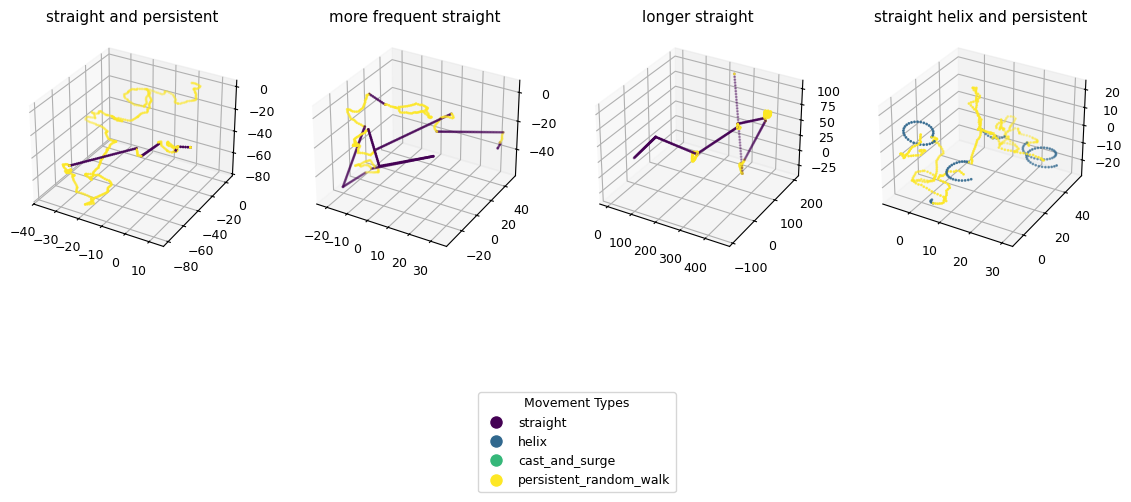

In [37]:

cmap = colormaps['viridis']
clr_dict ={'straight':cmap(0.),'helix':cmap(0.333),'cast_and_surge':cmap(0.666),'persistent_random_walk':cmap(1.)}
color_code = np.array([[clr_dict[mv] for mv in mvs[0]] for mvs in mvss])
fig,ax = plt.subplots(ncols=4,subplot_kw={'projection':'3d'},figsize=(14,3))
for i in range(4):
    ax[i].scatter(trjss[i][0][:,0],trjss[i][0][:,1],trjss[i][0][:,2],c=color_code[i],s=1)
    ax[i].set_title(descriptions[i])


legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=key,
           markerfacecolor=color, markersize=10)
    for key, color in clr_dict.items()
]
ax[0].legend(loc=(2.,-1.),handles=legend_elements, title="Movement Types")

In [38]:
labels = np.repeat(np.arange(nsample), ttot)
frames = np.tile(np.arange(ttot), nsample)

dfs = list()

for trjs,mvs in zip(trjss,mvss):
    flat_trjs = trjs.reshape(-1,3)
    flat_mvs = [item for sublist in mvs for item in sublist]
    df = pd.DataFrame(flat_trjs, columns=['x', 'y', 'z'])
    df['label'] = labels
    df['frame'] = frames
    df['move_type'] = flat_mvs
    dfs.append(df)

In [39]:
# Use this T if all the trajectories have different length
Ts = [[trj.__len__() for trj in trjs] for trjs in trjss]
print(Ts)

[[500, 500, 500, 500, 500, 500, 500, 500, 500, 500], [500, 500, 500, 500, 500, 500, 500, 500, 500, 500], [500, 500, 500, 500, 500, 500, 500, 500, 500, 500], [500, 500, 500, 500, 500, 500, 500, 500, 500, 500]]


### Optimize the entropy production based on nc and K

In [40]:
columns_abs = []
columns_translated = ['x','y','z']
id = 'label'
time = 'frame'

Klist = [3,5,10,20]
nc_list = [10,20,50,100]

embs = list()
for df in dfs:
    embs.append(EmbeddingTrans(df,columns=columns_abs,columns_translated=columns_translated,ID_NAME=id,label_col='move_type'))

H = np.zeros((len(embs),len(Klist),len(nc_list)),dtype=float)

for i,K in enumerate(Klist):
    print(i)
    for emb in embs:
        emb.make_embedding(K=K)
    for j,nc in enumerate(nc_list):
        for emb in embs:
            emb.make_cluster(n_clusters=nc)
        mkvs = list()
        for emb in embs:
            mkvs.append(Markov(emb,tau=1))
        for k,mkv in enumerate(mkvs):
            H[k,i,j] = mkv.compute_entropy_rate()

0
1
2
3


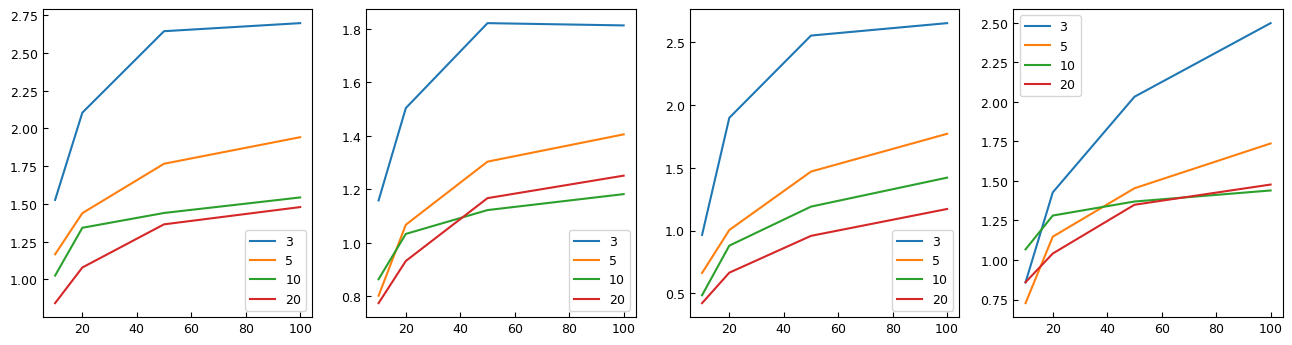

In [41]:
fig,ax = plt.subplots(ncols = len(embs),figsize=(4*len(embs),4))
for k in range(H.shape[0]):
    for i,h in enumerate(H[k]):
        ax[k].plot(nc_list,h,label=Klist[i])
    ax[k].legend()

### Build the different class instances

In [42]:
columns_abs = []
columns_translated = ['x','y','z']
id = 'label'
time = 'frame'

embs = list()
for df in dfs:
    embs.append(EmbeddingTrans(df,columns=columns_abs,columns_translated=columns_translated,ID_NAME=id,label_col='move_type'))

In [43]:
for emb in embs:
    emb.make_embedding(K=10)
    emb.make_cluster(n_clusters=50)

mkvs = list()
for emb in embs:
    mkvs.append(Markov(emb,tau=1))

### Clusterize them together

In [45]:
from src.cluster import Cluster
from scipy.special import entr
#nc_com_list = [50,60,70,80,90,100]
#for nc in nc_com_list:
#    clt = Cluster(100)
#    clt.add_embedding(embs[0])
#    clt.add_embedding(embs[1])
#    clt.set_shape_and_flatten()
#    clt.clusterize()
#
#    mkv = Markov()

In [49]:
clt = Cluster(50)
clt.add_embedding(embs[0])
clt.add_embedding(embs[1])
clt.set_shape_and_flatten()
clt.clusterize()

In [70]:
prop = clt.compute_proportions()
#print(entr(prop))

print((np.sum(entr(prop),axis=1)))# + np.log(0.5))/np.log(0.5))


[0.68542021 0.69204815 0.69309178 0.62961711 0.69127179 0.6844385
 0.6922017  0.68604418 0.67604834 0.69223376 0.66520426 0.69300354
 0.67621783 0.66550354 0.67301167 0.67071652 0.69311518 0.69135635
 0.67379869 0.6604714  0.69046781 0.68976562 0.67282609 0.66196859
 0.64458732 0.69002759 0.66627844 0.69293015 0.68419553 0.65350632
 0.64998788 0.69225423 0.69179727 0.69306285 0.69314718 0.69009827
 0.67047765 0.67503626 0.66795216 0.65548177 0.68860515 0.61974787
 0.60653676 0.65990404 0.68836256 0.69231396 0.68074892 0.67407345
 0.66696041 0.64650365]


In [69]:
print(entr(0.5))
print(-np.log(0.5))

0.34657359027997264
0.6931471805599453
